# 02_eda_visualizations.ipynb
# Capstone Project: Housing Affordability Stress in High-Growth U.S. Metros
# Author: Shyamsunder Mutcha
# Date: March 2026

In [135]:
import os

# Precedence Check: EDA requires the cleaned data from Notebook 01
if not os.path.exists('../data/cleaned_housing_affordability.csv'):
    print("Cleaned data not found. Running Data Ingestion (01) first...")
    %run 01_data_ingestion_cleaning.ipynb
else:
    print("Found cleaned data. Proceeding to EDA.")

Cleaned data not found. Running Data Ingestion (01) first...
Capstone - Data Ingestion and Cleaning
Goal: Load data for selected metros including Apex, NC and save cleaned version

Cleaned dataset:


,Metro_Area,Unemployment_Rate,Tech_Wage_Median,Median_Home_Value,Median_Income,Rent_Burden_Pct,Price_to_Income_Ratio,High_Stress
0,Raleigh-Cary NC (Apex),3.2,125000,565000,141000,28.5,4.007092,1
1,Austin TX,3.5,130000,520000,95000,30.0,5.473684,1
2,Charlotte NC,3.8,110000,380000,75000,32.0,5.066667,1
3,Seattle WA,4.0,145000,850000,115000,35.0,7.391304,1
4,San Francisco CA,3.1,160000,1200000,140000,38.0,8.571429,1
5,Boston MA,3.4,135000,650000,95000,33.0,6.842105,1
6,Denver CO,3.6,120000,550000,85000,31.0,6.470588,1
7,Portland OR,4.2,115000,520000,80000,32.0,6.500000,1
8,Atlanta GA,3.7,105000,400000,70000,34.0,5.714286,1
9,Phoenix AZ,4.0,100000,450000,75000,33.0,6.000000,1



DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Metro_Area             18 non-null     str    
 1   Unemployment_Rate      18 non-null     float64
 2   Tech_Wage_Median       18 non-null     int64  
 3   Median_Home_Value      18 non-null     int64  
 4   Median_Income          18 non-null     int64  
 5   Rent_Burden_Pct        18 non-null     float64
 6   Price_to_Income_Ratio  18 non-null     float64
 7   High_Stress            18 non-null     int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 1.3 KB

Descriptive statistics:

Missing values:
Metro_Area               0
Unemployment_Rate        0
Tech_Wage_Median         0
Median_Home_Value        0
Median_Income            0
Rent_Burden_Pct          0
Price_to_Income_Ratio    0
High_Stress              0
dtype: int64

Class distribution for High_Stress:
High_S

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [138]:
# Ensure plots directory exists
plots_dir = '../plots'
os.makedirs(plots_dir, exist_ok=True)

In [139]:
# Load cleaned dataset
df = pd.read_csv('../data/cleaned_housing_affordability.csv')

In [140]:
# Data overview
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Metro_Area             18 non-null     str    
 1   Unemployment_Rate      18 non-null     float64
 2   Tech_Wage_Median       18 non-null     int64  
 3   Median_Home_Value      18 non-null     int64  
 4   Median_Income          18 non-null     int64  
 5   Rent_Burden_Pct        18 non-null     float64
 6   Price_to_Income_Ratio  18 non-null     float64
 7   High_Stress            18 non-null     int64  
dtypes: float64(3), int64(4), str(1)
memory usage: 1.3 KB


,Unemployment_Rate,Tech_Wage_Median,Median_Home_Value,Median_Income,Rent_Burden_Pct,Price_to_Income_Ratio,High_Stress
count,18.000000,18.000000,1.800000e+01,18.000000,18.000000,18.000000,18.000000
mean,3.788889,112666.666667,4.537611e+05,88421.111111,29.583333,4.936010,0.611111
std,0.359557,19592.915887,2.548390e+05,21803.810214,4.260799,1.757745,0.501631
min,3.100000,90000.000000,2.100000e+05,70000.000000,23.000000,2.916667,0.000000
25%,3.525000,98000.000000,2.650000e+05,75000.000000,26.125000,3.291159,0.000000
50%,3.800000,107500.000000,3.900000e+05,80000.000000,30.000000,4.763824,1.000000
75%,4.075000,123750.000000,5.425000e+05,92500.000000,32.750000,6.352941,1.000000
max,4.400000,160000.000000,1.200000e+06,141000.000000,38.000000,8.571429,1.000000


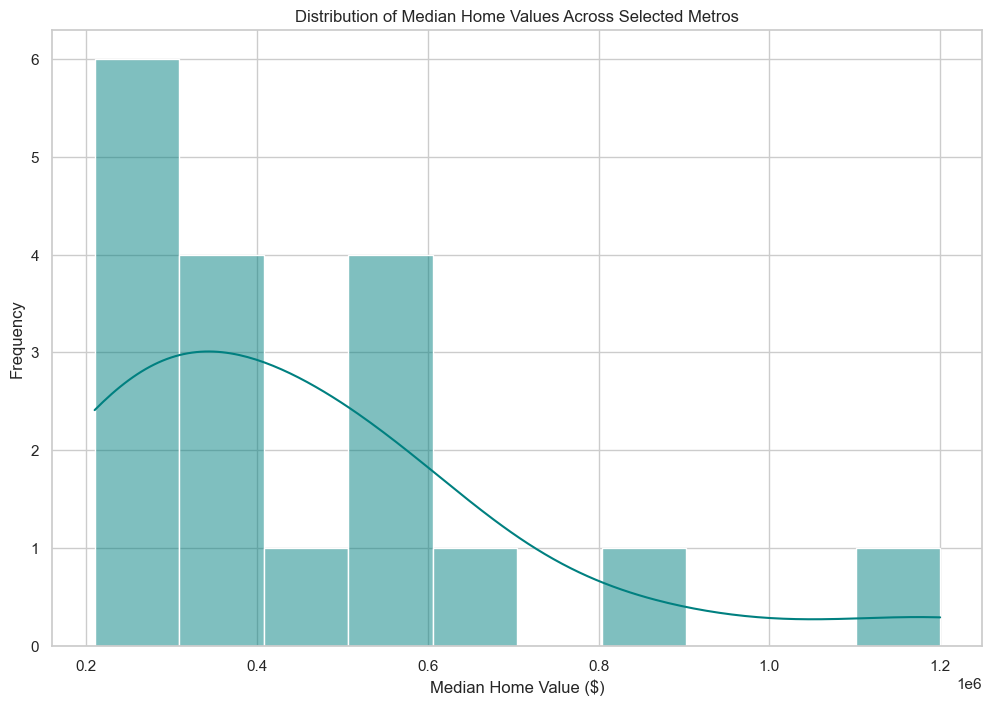

In [141]:
# Distribution of median home values
# Utilizing Seaborn's histplot with a Kernel Density Estimate (KDE)
# to visualize the shape and skewness of home value distributions.
plt.figure()
sns.histplot(df['Median_Home_Value'], kde=True, color='teal', bins=10)
plt.title('Distribution of Median Home Values Across Selected Metros')
plt.xlabel('Median Home Value ($)')
plt.ylabel('Frequency')
plt.savefig(os.path.join(plots_dir, '01_home_value_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

**Observation**: The heatmap shows a strong positive correlation between Tech Median Wages and Home Values, suggesting that higher income levels in the tech sector are a significant driver of local real estate pricing.

**Key Insight:** The strong positive correlation between Tech Wages and Price-to-Income ratios suggests that housing stress in these regions is highly sensitive to salary growth in the technology sector.

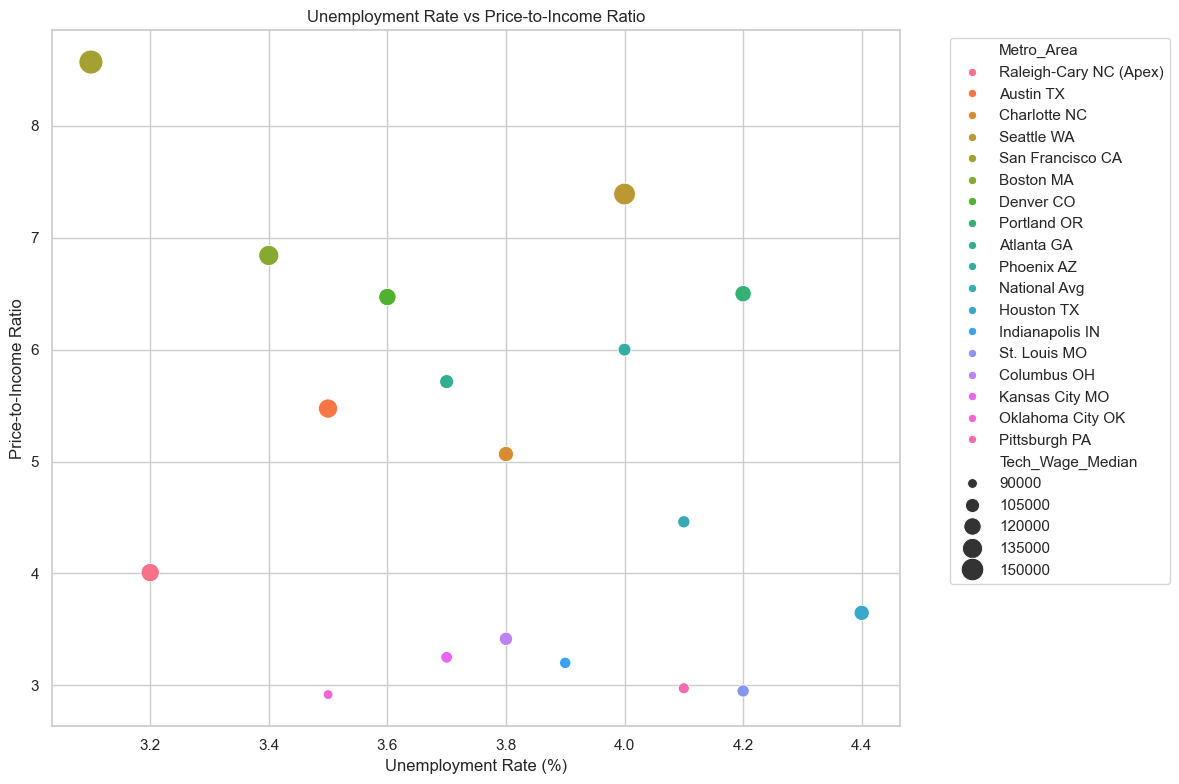

In [142]:
# Scatter: Unemployment vs Price-to-Income Ratio
plt.figure()
sns.scatterplot(data=df, x='Unemployment_Rate', y='Price_to_Income_Ratio',
                hue='Metro_Area', size='Tech_Wage_Median', sizes=(50, 300))
plt.title('Unemployment Rate vs Price-to-Income Ratio')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Price-to-Income Ratio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '02_unemployment_vs_affordability.png'), dpi=300, bbox_inches='tight')
plt.show()

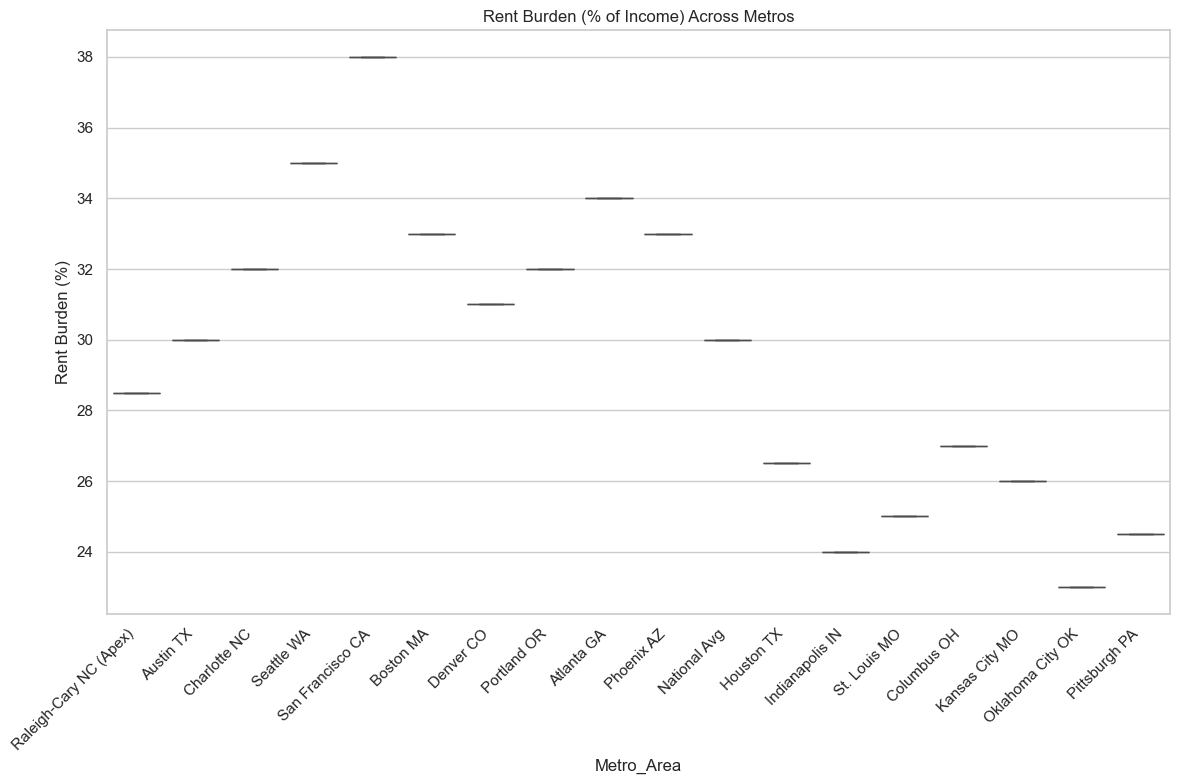

In [143]:
# Boxplot: Rent Burden by Metro
plt.figure()
sns.boxplot(data=df, y='Rent_Burden_Pct', x='Metro_Area')
plt.title('Rent Burden (% of Income) Across Metros')
plt.ylabel('Rent Burden (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '03_rent_burden_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

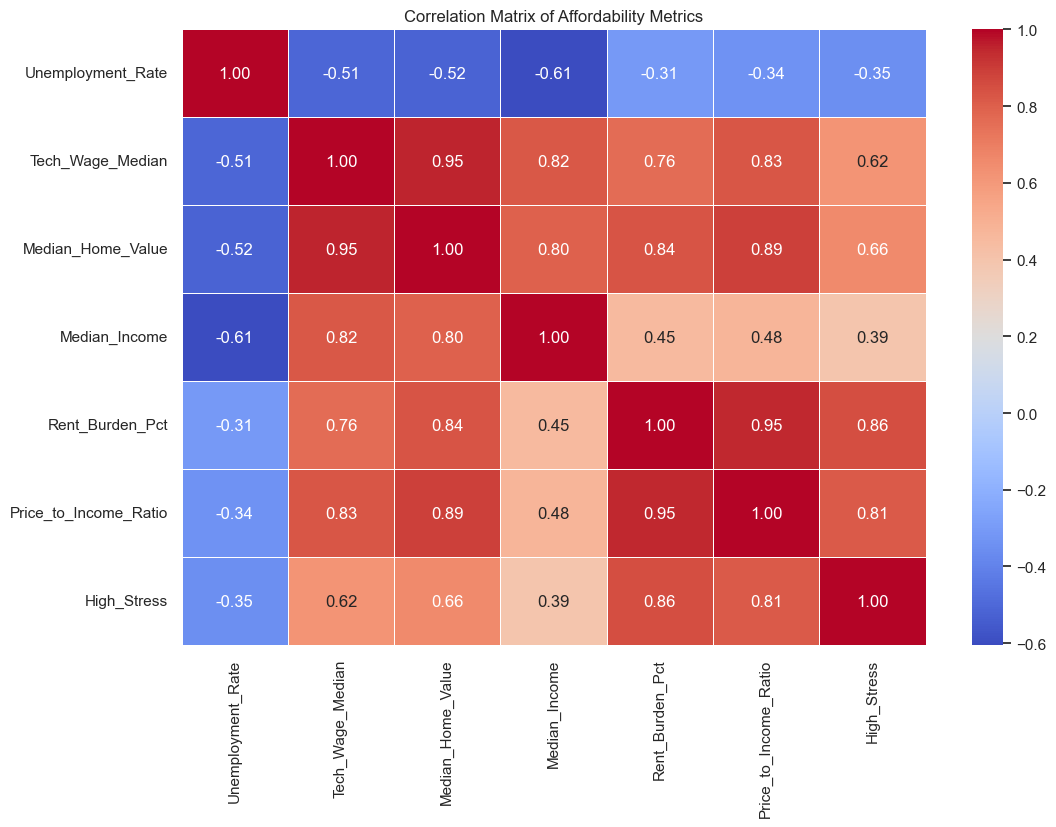

In [144]:
# Correlation heatmap
plt.figure()
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Affordability Metrics')
plt.savefig(os.path.join(plots_dir, '04_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

In [145]:
# Summary statistics for key metrics
print("Key Metrics Summary:")
print(df[['Unemployment_Rate', 'Price_to_Income_Ratio', 'Rent_Burden_Pct']].describe())

Key Metrics Summary:
       Unemployment_Rate  Price_to_Income_Ratio  Rent_Burden_Pct
count          18.000000              18.000000        18.000000
mean            3.788889               4.936010        29.583333
std             0.359557               1.757745         4.260799
min             3.100000               2.916667        23.000000
25%             3.525000               3.291159        26.125000
50%             3.800000               4.763824        30.000000
75%             4.075000               6.352941        32.750000
max             4.400000               8.571429        38.000000


## Key EDA Observations
- Median home values are right-skewed, especially in high-growth tech metros.
- Lower unemployment rates tend to coincide with higher price-to-income ratios.
- Rent burden is moderate overall, but varies across metros.
- Tech wages show positive correlation with home values, suggesting income growth doesn't fully offset housing cost increases.